In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
sys.path.insert(0,'/content/drive/MyDrive/Heatmaps/')
!ls '/content/drive/MyDrive/Heatmaps/'

cnn_saved_models	New_test_heatmaps
custom_resnet_results	New_train_heatmaps
final_cnn_results	New_train_heatmaps-20251205T192432Z-3-001.zip
louo_cnn_results	resnet_models
louo_simplecnn_results	simplecnn_models


Held out user -User 1  Training starting at 2.35

Device: cuda
Saving to: /content/drive/MyDrive/Heatmaps/louo_cnn_results/user1_heldout
Scanning users: ['user2', 'user3', 'user4', 'user5']
Total samples (train users only): 2489
Train/Val samples (train users only): 1991/498
Test samples (held-out user): 408
Epoch 01/40 | Train Loss 1.2329 Acc 0.7770 | Val Loss 0.2856 Acc 0.8896
Epoch 02/40 | Train Loss 0.3621 Acc 0.8619 | Val Loss 0.3354 Acc 0.8976
Epoch 03/40 | Train Loss 0.2994 Acc 0.8850 | Val Loss 0.2389 Acc 0.8855
Epoch 04/40 | Train Loss 0.2469 Acc 0.8955 | Val Loss 0.1991 Acc 0.9016
Epoch 05/40 | Train Loss 0.2401 Acc 0.8990 | Val Loss 0.2133 Acc 0.8996
Epoch 06/40 | Train Loss 0.2373 Acc 0.8920 | Val Loss 0.2791 Acc 0.9096
Epoch 07/40 | Train Loss 0.2311 Acc 0.9026 | Val Loss 0.1908 Acc 0.8855
Epoch 08/40 | Train Loss 0.2227 Acc 0.9066 | Val Loss 0.1810 Acc 0.9056
Epoch 09/40 | Train Loss 0.2214 Acc 0.9081 | Val Loss 0.2049 Acc 0.9116
Epoch 10/40 | Train Loss 0.2329 Acc 0.9056 | Val Loss 0.1740 Acc 0.9076
Epoch 11/40 | Train 

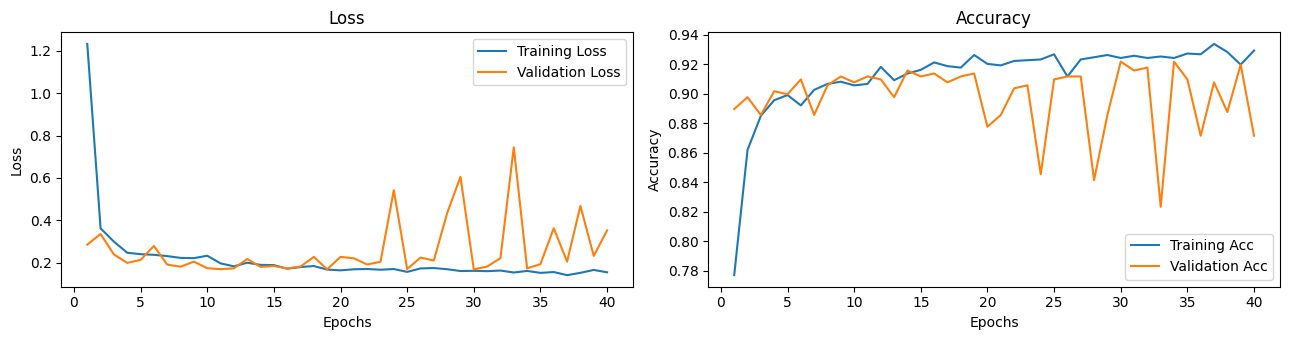

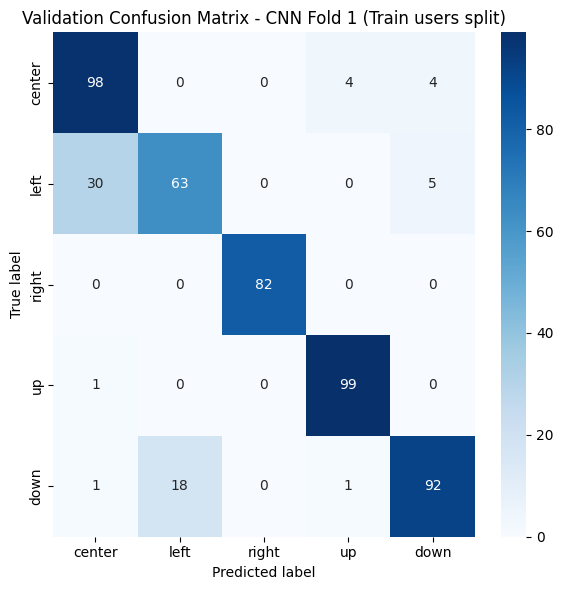


VALIDATION METRICS TABLE - CNN Fold 1
-------------------------------------
class         precision     recall   f1-score    support
--------------------------------------------------------
center             0.75       0.92       0.83        106
left               0.78       0.64       0.70         98
right              1.00       1.00       1.00         82
up                 0.95       0.99       0.97        100
down               0.91       0.82       0.86        112
macro avg          0.88       0.88       0.87        498
weighted avg       0.87       0.87       0.87        498
accuracy           0.87       0.87       0.87        498

FINAL TEST Accuracy - CNN Fold 1 (Held-out user1): 0.7868


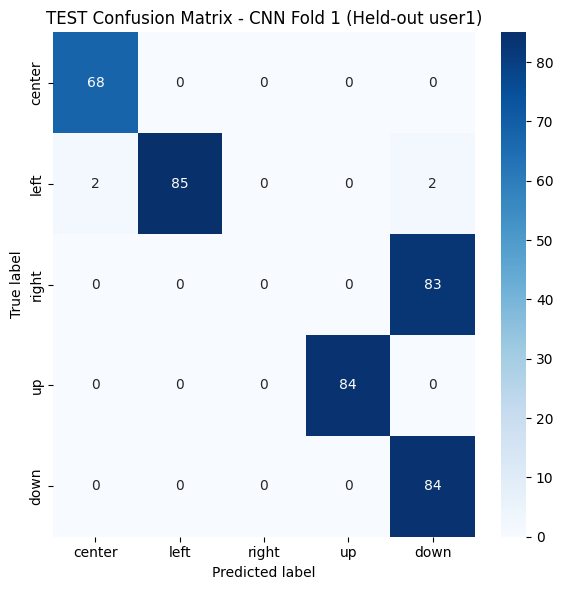


TEST METRICS TABLE - CNN Fold 1 (Held-out user1)
------------------------------------------------
class         precision     recall   f1-score    support
--------------------------------------------------------
center             0.97       1.00       0.99         68
left               1.00       0.96       0.98         89
right              0.00       0.00       0.00         83
up                 1.00       1.00       1.00         84
down               0.50       1.00       0.66         84
macro avg          0.69       0.79       0.73        408
weighted avg       0.69       0.79       0.72        408
accuracy           0.79       0.79       0.79        408

Saved in: /content/drive/MyDrive/Heatmaps/louo_cnn_results/user1_heldout
 - loss_acc_curves_fold{FOLD}.png
 - val_confusion_matrix_fold{FOLD}.png
 - test_confusion_matrix_fold{FOLD}.png
 - val/test_classification_report_fold{FOLD}.txt
 - best model: /content/drive/MyDrive/Heatmaps/louo_cnn_results/user1_heldout/best_cnn_fold1.pt

In [3]:
# ============================================================
# LOUO CNN (Fold 1): Train on user2-5, Val split (80/20) on those 4 users,
# Test on unseen user1 from New_test_heatmaps/user1_test.npz
#
# Architecture (EXACT):
# - Input: RGB resized to 224x224
# - Conv blocks:
#   (3->32)->BN->ReLU->MaxPool
#   (32->64)->BN->ReLU->MaxPool
#   (64->128)->BN->ReLU->MaxPool
#   (128->256)->BN->ReLU->MaxPool
# - Flatten: 256*14*14 = 50176
# - FC: 50176->512->ReLU->Dropout(0.5)
# - Classifier: 512->5
#
# Training config (EXACT):
# - Loss: CrossEntropy
# - Optimizer: Adam(lr=5e-4, weight_decay=1e-4)
# ============================================================

import os, glob, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------
# CONFIG
DRIVE_ROOT = "/content/drive/MyDrive"
TRAIN_ROOT = os.path.join(DRIVE_ROOT, "Heatmaps", "New_train_heatmaps")
TEST_ROOT  = os.path.join(DRIVE_ROOT, "Heatmaps", "New_test_heatmaps")

FOLD = 1
ALL_USERS = ["user1", "user2", "user3", "user4", "user5"]
HELD_OUT_USER = "user1"
TRAIN_USERS = [u for u in ALL_USERS if u != HELD_OUT_USER]

NUM_CLASSES = 5
BATCH_SIZE = 32
EPOCHS = 40
LR = 5e-4
WEIGHT_DECAY = 1e-4
IMG_SIZE = 224

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

LABEL_MAP = {"center": 0, "left": 1, "right": 2, "up": 3, "down": 4}
LABELS = ["center", "left", "right", "up", "down"]

SAVE_DIR = os.path.join(DRIVE_ROOT, "Heatmaps", "louo_cnn_results", f"{HELD_OUT_USER}_heldout")
os.makedirs(SAVE_DIR, exist_ok=True)
print("Saving to:", SAVE_DIR)

# -----------------------
# NPZ loader for userX_test.npz that contains images+labels
def load_npz_images_labels(path):
    d = np.load(path, allow_pickle=True)
    keys = d.files
    if "heatmaps" in keys and "labels" in keys:
        return d["heatmaps"], d["labels"]
    if "images" in keys and "labels" in keys:
        return d["images"], d["labels"]
    if "X" in keys and "y" in keys:
        return d["X"], d["y"]
    raise ValueError(f"Test NPZ format not recognized. Keys found: {keys}")

# -----------------------
# Training-file loader (supports heatmaps/images/X + labels/y or infer from filename)
def find_data_and_labels(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    keys = d.files

    if "heatmaps" in keys:
        X = d["heatmaps"]
    elif "images" in keys:
        X = d["images"]
    elif "X" in keys:
        X = d["X"]
    else:
        X = d[keys[0]]

    if "labels" in keys:
        y = d["labels"]
    elif "y" in keys:
        y = d["y"]
    else:
        fname = os.path.basename(npz_path).lower()
        lab = None
        for name, idx in LABEL_MAP.items():
            if name in fname:
                lab = idx
                break
        if lab is None:
            raise ValueError(f"Cannot infer label from filename: {npz_path}")
        y = np.full((X.shape[0],), lab, dtype=np.int64)

    return X, y

# -----------------------
# Dataset for training users: root/user/*.npz (each frame is a sample)
class UserHeatmapDataset(Dataset):
    def __init__(self, root_dir, user_list, image_size=224):
        self.samples = []  # (npz_path, frame_idx, label)
        self.cache = {}
        self.image_size = image_size

        print(f"Scanning users: {user_list}")
        for user in user_list:
            user_dir = os.path.join(root_dir, user)
            if not os.path.isdir(user_dir):
                print("Missing:", user_dir)
                continue

            for f in glob.glob(os.path.join(user_dir, "*.npz")):
                try:
                    X_f, y_f = find_data_and_labels(f)
                    if X_f.shape[0] == 0:
                        continue
                    for i in range(X_f.shape[0]):
                        self.samples.append((f, i, int(y_f[i])))
                except Exception:
                    pass

        print("Total samples (train users only):", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def _load_npz(self, npz_path):
        if npz_path not in self.cache:
            d = np.load(npz_path, allow_pickle=True)
            keys = d.files
            if "heatmaps" in keys:
                self.cache[npz_path] = d["heatmaps"]
            elif "images" in keys:
                self.cache[npz_path] = d["images"]
            elif "X" in keys:
                self.cache[npz_path] = d["X"]
            else:
                self.cache[npz_path] = d[keys[0]]
        return self.cache[npz_path]

    def __getitem__(self, idx):
        npz_path, frame_idx, label = self.samples[idx]
        arr = self._load_npz(npz_path)
        img = np.asarray(arr[frame_idx]).astype(np.float32)

        # Safety: if CHW -> HWC
        if img.ndim == 3 and img.shape[0] == 3 and img.shape[-1] != 3:
            img = np.transpose(img, (1, 2, 0))

        # Normalize per-image to 0..1 (kept consistent with your ResNet preprocessing)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # Ensure 3 channels
        if img.ndim == 2:
            img = np.stack([img, img, img], axis=-1)
        elif img.ndim == 3 and img.shape[-1] == 1:
            img = np.concatenate([img, img, img], axis=-1)

        x = torch.from_numpy(img).permute(2, 0, 1)  # C,H,W
        x = (x - 0.5) / 0.5

        x = F.interpolate(
            x.unsqueeze(0),
            size=(self.image_size, self.image_size),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        return x, int(label)

# -----------------------
# Dataset for held-out test arrays in userX_test.npz
class HeatmapArrayDataset(Dataset):
    def __init__(self, images, labels, image_size=224):
        self.images = np.asarray(images)
        self.labels = np.asarray(labels).astype(np.int64)
        self.image_size = image_size

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        img = self.images[i].astype(np.float32)

        # Safety: if CHW -> HWC
        if img.ndim == 3 and img.shape[0] == 3 and img.shape[-1] != 3:
            img = np.transpose(img, (1, 2, 0))

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        if img.ndim == 2:
            img = np.stack([img, img, img], axis=-1)
        elif img.ndim == 3 and img.shape[-1] == 1:
            img = np.concatenate([img, img, img], axis=-1)

        x = torch.from_numpy(img).permute(2, 0, 1)
        x = (x - 0.5) / 0.5

        x = F.interpolate(
            x.unsqueeze(0),
            size=(self.image_size, self.image_size),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        return x, int(self.labels[i])

# -----------------------
# CNN (EXACT architecture you provided)
class RobustCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        # Block 1: 3 -> 32
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)  # 224->112

        # Block 2: 32 -> 64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)  # 112->56

        # Block 3: 64 -> 128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)  # 56->28

        # Block 4: 128 -> 256
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2, 2)  # 28->14

        # Flatten: 256*14*14 = 50176
        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.drop = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)

# -----------------------
# Plot helpers (same as ResNet style: Blues, PPT-friendly)
def plot_confusion(cm, title, save_path):
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
                xticklabels=LABELS, yticklabels=LABELS)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

def plot_curves(train_losses, val_losses, train_accs, val_accs, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

    axes[0].plot(range(1, len(train_losses)+1), train_losses, linestyle='-', color='tab:blue', label="Training Loss")
    axes[0].plot(range(1, len(val_losses)+1),   val_losses,   linestyle='-', color='tab:orange', label="Validation Loss")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].set_title("Loss")

    axes[1].plot(range(1, len(train_accs)+1), train_accs, linestyle='-', color='tab:blue', label="Training Acc")
    axes[1].plot(range(1, len(val_accs)+1),   val_accs,   linestyle='-', color='tab:orange', label="Validation Acc")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].set_title("Accuracy")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

# Metrics table like “metrics table” output
def make_metrics_table(y_true, y_pred):
    p, r, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(NUM_CLASSES)), zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)

    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    rows = []
    for i, lab in enumerate(LABELS):
        rows.append([lab, p[i], r[i], f1[i], int(sup[i])])

    rows.append(["macro avg", p_macro, r_macro, f1_macro, int(np.sum(sup))])
    rows.append(["weighted avg", p_w, r_w, f1_w, int(np.sum(sup))])
    rows.append(["accuracy", acc, acc, acc, int(np.sum(sup))])

    return rows

def print_metrics_table(rows, title):
    print("\n" + title)
    print("-" * len(title))
    header = f"{'class':<12} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>10}"
    print(header)
    print("-" * len(header))
    for (cls, p, r, f1, sup) in rows:
        print(f"{cls:<12} {p:>10.2f} {r:>10.2f} {f1:>10.2f} {sup:>10}")

# ============================================================
# 1) Build train dataset from 4 users (ALL samples)
# ============================================================
full_train_dataset = UserHeatmapDataset(TRAIN_ROOT, TRAIN_USERS, image_size=IMG_SIZE)

# 80/20 split (train users only)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_ds, val_ds = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train/Val samples (train users only): {train_size}/{val_size}")

# ============================================================
# 2) Load held-out test user1_test.npz
# ============================================================
test_path = os.path.join(TEST_ROOT, f"{HELD_OUT_USER}_test.npz")
test_imgs, test_labels = load_npz_images_labels(test_path)
test_ds = HeatmapArrayDataset(test_imgs, test_labels, image_size=IMG_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print("Test samples (held-out user):", len(test_ds))

# ============================================================
# 3) Train CNN (exact config)
# ============================================================
model = RobustCNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0
best_path = os.path.join(SAVE_DIR, f"best_cnn_fold{FOLD}.pt")

for epoch in range(1, EPOCHS + 1):
    # ---- Train ----
    model.train()
    correct, total, loss_sum = 0, 0, 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device).float(), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * xb.size(0)
        pred = out.argmax(1)
        correct += (pred == yb).sum().item()
        total += xb.size(0)

    tr_loss = loss_sum / total
    tr_acc = correct / total

    # ---- Val ----
    model.eval()
    v_correct, v_total, v_loss_sum = 0, 0, 0.0
    val_preds, val_true = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device).float(), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)

            v_loss_sum += loss.item() * xb.size(0)
            pred = out.argmax(1)

            v_correct += (pred == yb).sum().item()
            v_total += xb.size(0)

            val_preds.append(pred.cpu().numpy())
            val_true.append(yb.cpu().numpy())

    v_loss = v_loss_sum / v_total
    v_acc = v_correct / v_total

    train_losses.append(tr_loss)
    val_losses.append(v_loss)
    train_accs.append(tr_acc)
    val_accs.append(v_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
          f"Val Loss {v_loss:.4f} Acc {v_acc:.4f}")

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), best_path)

# ============================================================
# 4) Curves + VALIDATION confusion matrix + metrics table
# ============================================================
plot_curves(
    train_losses, val_losses, train_accs, val_accs,
    save_path=os.path.join(SAVE_DIR, f"loss_acc_curves_fold{FOLD}.png")
)

val_preds = np.concatenate(val_preds)
val_true  = np.concatenate(val_true)

cm_val = confusion_matrix(val_true, val_preds, labels=list(range(NUM_CLASSES)))
plot_confusion(
    cm_val,
    title=f"Validation Confusion Matrix - CNN Fold {FOLD} (Train users split)",
    save_path=os.path.join(SAVE_DIR, f"val_confusion_matrix_fold{FOLD}.png")
)

val_rows = make_metrics_table(val_true, val_preds)
print_metrics_table(val_rows, title=f"VALIDATION METRICS TABLE - CNN Fold {FOLD}")

with open(os.path.join(SAVE_DIR, f"val_classification_report_fold{FOLD}.txt"), "w") as f:
    f.write(classification_report(val_true, val_preds, target_names=LABELS, zero_division=0))

# ============================================================
# 5) FINAL TEST on held-out user1: confusion matrix + metrics table
# ============================================================
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

test_preds, test_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device).float()
        out = model(xb)
        pred = out.argmax(1)
        test_preds.append(pred.cpu().numpy())
        test_true.append(np.asarray(yb))

test_preds = np.concatenate(test_preds)
test_true  = np.concatenate(test_true)

test_acc = (test_preds == test_true).mean() if len(test_true) else 0.0
print(f"\nFINAL TEST Accuracy - CNN Fold {FOLD} (Held-out {HELD_OUT_USER}): {test_acc:.4f}")

cm_test = confusion_matrix(test_true, test_preds, labels=list(range(NUM_CLASSES)))
plot_confusion(
    cm_test,
    title=f"TEST Confusion Matrix - CNN Fold {FOLD} (Held-out {HELD_OUT_USER})",
    save_path=os.path.join(SAVE_DIR, f"test_confusion_matrix_fold{FOLD}.png")
)

test_rows = make_metrics_table(test_true, test_preds)
print_metrics_table(test_rows, title=f"TEST METRICS TABLE - CNN Fold {FOLD} (Held-out {HELD_OUT_USER})")

with open(os.path.join(SAVE_DIR, f"test_classification_report_fold{FOLD}.txt"), "w") as f:
    f.write(classification_report(test_true, test_preds, target_names=LABELS, zero_division=0))

print("\nSaved in:", SAVE_DIR)
print(" - loss_acc_curves_fold{FOLD}.png")
print(" - val_confusion_matrix_fold{FOLD}.png")
print(" - test_confusion_matrix_fold{FOLD}.png")
print(" - val/test_classification_report_fold{FOLD}.txt")
print(" - best model:", best_path)


Held out User -User 2

Device: cuda
Saving plots/results to: /content/drive/MyDrive/Heatmaps/louo_cnn_results/user2_heldout
Saving model checkpoints to: /content/drive/MyDrive/Heatmaps/cnn_saved_models
Scanning TRAIN users: ['user1', 'user3', 'user4', 'user5']
Total samples (train users only): 2627
Train/Val samples (train users only): 2101/526
Test samples (held-out user): 407
Epoch 01/40 | Train Loss 0.9822 Acc 0.8306 | Val Loss 0.2133 Acc 0.9202
Epoch 02/40 | Train Loss 0.2840 Acc 0.9077 | Val Loss 0.1942 Acc 0.9392
Epoch 03/40 | Train Loss 0.2244 Acc 0.9167 | Val Loss 0.1269 Acc 0.9582
Epoch 04/40 | Train Loss 0.1934 Acc 0.9234 | Val Loss 0.1445 Acc 0.9297
Epoch 05/40 | Train Loss 0.1690 Acc 0.9324 | Val Loss 0.1212 Acc 0.9544
Epoch 06/40 | Train Loss 0.1769 Acc 0.9272 | Val Loss 0.1142 Acc 0.9601
Epoch 07/40 | Train Loss 0.1415 Acc 0.9376 | Val Loss 0.1246 Acc 0.9430
Epoch 08/40 | Train Loss 0.1422 Acc 0.9324 | Val Loss 0.1242 Acc 0.9620
Epoch 09/40 | Train Loss 0.1555 Acc 0.9319 | Val Loss 0.1037 Acc 0

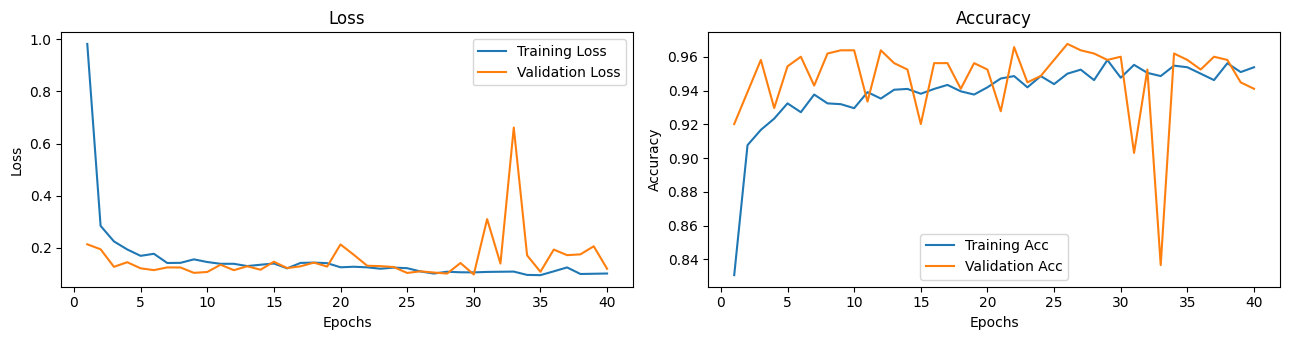

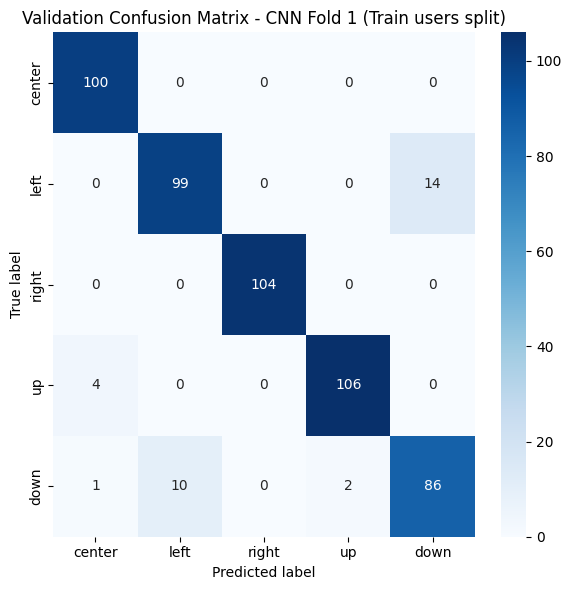


VALIDATION METRICS TABLE - CNN Fold 1
-------------------------------------
class         precision     recall   f1-score    support
--------------------------------------------------------
center             0.95       1.00       0.98        100
left               0.91       0.88       0.89        113
right              1.00       1.00       1.00        104
up                 0.98       0.96       0.97        110
down               0.86       0.87       0.86         99
macro avg          0.94       0.94       0.94        526
weighted avg       0.94       0.94       0.94        526
accuracy           0.94       0.94       0.94        526

FINAL TEST Accuracy - CNN Fold 1 (Held-out user2): 0.8305


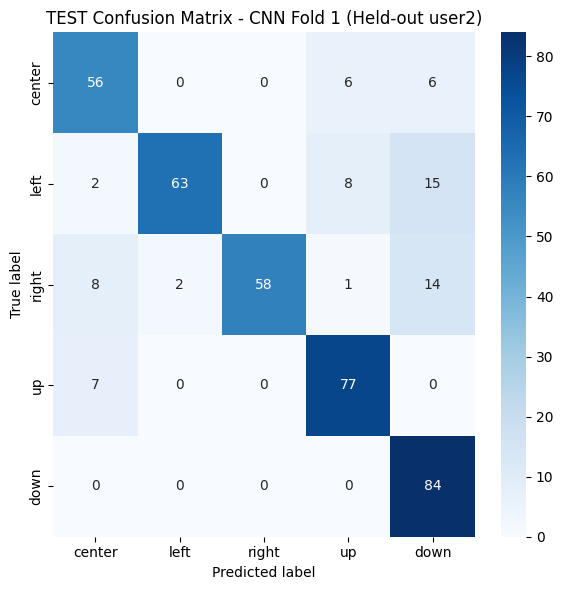


TEST METRICS TABLE - CNN Fold 1 (Held-out user2)
------------------------------------------------
class         precision     recall   f1-score    support
--------------------------------------------------------
center             0.77       0.82       0.79         68
left               0.97       0.72       0.82         88
right              1.00       0.70       0.82         83
up                 0.84       0.92       0.88         84
down               0.71       1.00       0.83         84
macro avg          0.86       0.83       0.83        407
weighted avg       0.86       0.83       0.83        407
accuracy           0.83       0.83       0.83        407

Saved:
 - Best CNN checkpoint: /content/drive/MyDrive/Heatmaps/cnn_saved_models/cnn_best_user2.pt
 - Plots/reports folder: /content/drive/MyDrive/Heatmaps/louo_cnn_results/user2_heldout


In [4]:
# ============================================================
# LOUO CNN (Fold 1): Train user2-5, Val split 80/20 on those 4 users,
# Test on unseen user1_test.npz
# Saves best model: saved_models/cnn_best_user1.pt
# ============================================================

import os, glob, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------
# CONFIG
DRIVE_ROOT = "/content/drive/MyDrive"
TRAIN_ROOT = os.path.join(DRIVE_ROOT, "Heatmaps", "New_train_heatmaps")
TEST_ROOT  = os.path.join(DRIVE_ROOT, "Heatmaps", "New_test_heatmaps")

FOLD = 1
ALL_USERS = ["user1", "user3", "user4", "user5"]
HELD_OUT_USER = "user2"
TRAIN_USERS = [u for u in ALL_USERS if u != HELD_OUT_USER]

NUM_CLASSES = 5
BATCH_SIZE = 32
EPOCHS = 40
LR = 5e-4
WEIGHT_DECAY = 1e-4
IMG_SIZE = 224

LABEL_MAP = {"center": 0, "left": 1, "right": 2, "up": 3, "down": 4}
LABELS = ["center", "left", "right", "up", "down"]

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Output folders
SAVE_DIR = os.path.join(DRIVE_ROOT, "Heatmaps", "louo_cnn_results", f"{HELD_OUT_USER}_heldout")
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_DIR = os.path.join(DRIVE_ROOT, "Heatmaps", "cnn_saved_models")
os.makedirs(MODEL_DIR, exist_ok=True)

print("Saving plots/results to:", SAVE_DIR)
print("Saving model checkpoints to:", MODEL_DIR)

# -----------------------
# NPZ loader for test file userX_test.npz
def load_npz_images_labels(path):
    d = np.load(path, allow_pickle=True)
    keys = d.files
    if "heatmaps" in keys and "labels" in keys:
        return d["heatmaps"], d["labels"]
    if "images" in keys and "labels" in keys:
        return d["images"], d["labels"]
    if "X" in keys and "y" in keys:
        return d["X"], d["y"]
    raise ValueError(f"Test NPZ format not recognized. Keys found: {keys}")

# Training-file loader (supports heatmaps/images/X + labels/y or infer from filename)
def find_data_and_labels(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    keys = d.files

    if "heatmaps" in keys:
        X = d["heatmaps"]
    elif "images" in keys:
        X = d["images"]
    elif "X" in keys:
        X = d["X"]
    else:
        X = d[keys[0]]

    if "labels" in keys:
        y = d["labels"]
    elif "y" in keys:
        y = d["y"]
    else:
        fname = os.path.basename(npz_path).lower()
        lab = None
        for name, idx in LABEL_MAP.items():
            if name in fname:
                lab = idx
                break
        if lab is None:
            raise ValueError(f"Cannot infer label from filename: {npz_path}")
        y = np.full((X.shape[0],), lab, dtype=np.int64)

    return X, y

# -----------------------
# Dataset for training users: root/user/*.npz (each frame is a sample)
class UserHeatmapDataset(Dataset):
    def __init__(self, root_dir, user_list, image_size=224):
        self.samples = []  # (npz_path, frame_idx, label)
        self.cache = {}
        self.image_size = image_size

        print(f"Scanning TRAIN users: {user_list}")
        for user in user_list:
            user_dir = os.path.join(root_dir, user)
            if not os.path.isdir(user_dir):
                print("Missing:", user_dir)
                continue

            for f in glob.glob(os.path.join(user_dir, "*.npz")):
                try:
                    X_f, y_f = find_data_and_labels(f)
                    if X_f.shape[0] == 0:
                        continue
                    for i in range(X_f.shape[0]):
                        self.samples.append((f, i, int(y_f[i])))
                except Exception:
                    pass

        print("Total samples (train users only):", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def _load_npz(self, npz_path):
        if npz_path not in self.cache:
            d = np.load(npz_path, allow_pickle=True)
            keys = d.files
            if "heatmaps" in keys:
                self.cache[npz_path] = d["heatmaps"]
            elif "images" in keys:
                self.cache[npz_path] = d["images"]
            elif "X" in keys:
                self.cache[npz_path] = d["X"]
            else:
                self.cache[npz_path] = d[keys[0]]
        return self.cache[npz_path]

    def __getitem__(self, idx):
        npz_path, frame_idx, label = self.samples[idx]
        arr = self._load_npz(npz_path)
        img = np.asarray(arr[frame_idx]).astype(np.float32)

        # Safety: if CHW -> HWC
        if img.ndim == 3 and img.shape[0] == 3 and img.shape[-1] != 3:
            img = np.transpose(img, (1, 2, 0))

        # Normalize per-image to 0..1 (kept consistent with your ResNet preprocessing)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # Ensure 3 channels
        if img.ndim == 2:
            img = np.stack([img, img, img], axis=-1)
        elif img.ndim == 3 and img.shape[-1] == 1:
            img = np.concatenate([img, img, img], axis=-1)

        x = torch.from_numpy(img).permute(2, 0, 1)  # C,H,W
        x = (x - 0.5) / 0.5

        x = F.interpolate(
            x.unsqueeze(0),
            size=(self.image_size, self.image_size),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        return x, int(label)

# Dataset for held-out test arrays in userX_test.npz
class HeatmapArrayDataset(Dataset):
    def __init__(self, images, labels, image_size=224):
        self.images = np.asarray(images)
        self.labels = np.asarray(labels).astype(np.int64)
        self.image_size = image_size

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        img = self.images[i].astype(np.float32)

        # Safety: if CHW -> HWC
        if img.ndim == 3 and img.shape[0] == 3 and img.shape[-1] != 3:
            img = np.transpose(img, (1, 2, 0))

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        if img.ndim == 2:
            img = np.stack([img, img, img], axis=-1)
        elif img.ndim == 3 and img.shape[-1] == 1:
            img = np.concatenate([img, img, img], axis=-1)

        x = torch.from_numpy(img).permute(2, 0, 1)
        x = (x - 0.5) / 0.5

        x = F.interpolate(
            x.unsqueeze(0),
            size=(self.image_size, self.image_size),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        return x, int(self.labels[i])

# -----------------------
# CNN ARCHITECTURE (EXACT)
class RobustCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4   = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(256 * 14 * 14, 512)  # 50176 -> 512
        self.drop = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)

# -----------------------
# Plot helpers (same style as ResNet outputs: Blues, PPT-friendly)
def plot_confusion(cm, title, save_path):
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
                xticklabels=LABELS, yticklabels=LABELS)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

def plot_curves(train_losses, val_losses, train_accs, val_accs, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

    axes[0].plot(range(1, len(train_losses)+1), train_losses, linestyle='-', color='tab:blue', label="Training Loss")
    axes[0].plot(range(1, len(val_losses)+1),   val_losses,   linestyle='-', color='tab:orange', label="Validation Loss")
    axes[0].set_xlabel("Epochs"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].set_title("Loss")

    axes[1].plot(range(1, len(train_accs)+1), train_accs, linestyle='-', color='tab:blue', label="Training Acc")
    axes[1].plot(range(1, len(val_accs)+1),   val_accs,   linestyle='-', color='tab:orange', label="Validation Acc")
    axes[1].set_xlabel("Epochs"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(); axes[1].set_title("Accuracy")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

def make_metrics_table(y_true, y_pred):
    p, r, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(NUM_CLASSES)), zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)

    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

    rows = []
    for i, lab in enumerate(LABELS):
        rows.append([lab, p[i], r[i], f1[i], int(sup[i])])
    rows.append(["macro avg", p_macro, r_macro, f1_macro, int(np.sum(sup))])
    rows.append(["weighted avg", p_w, r_w, f1_w, int(np.sum(sup))])
    rows.append(["accuracy", acc, acc, acc, int(np.sum(sup))])
    return rows

def print_metrics_table(rows, title):
    print("\n" + title)
    print("-" * len(title))
    header = f"{'class':<12} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>10}"
    print(header)
    print("-" * len(header))
    for cls, p, r, f1, sup in rows:
        print(f"{cls:<12} {p:>10.2f} {r:>10.2f} {f1:>10.2f} {sup:>10}")

# ============================================================
# 1) Build train dataset from 4 users (ALL samples) + 80/20 split
# ============================================================
full_train_dataset = UserHeatmapDataset(TRAIN_ROOT, TRAIN_USERS, image_size=IMG_SIZE)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_ds, val_ds = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train/Val samples (train users only): {train_size}/{val_size}")

# ============================================================
# 2) Load held-out test user1_test.npz
# ============================================================
test_path = os.path.join(TEST_ROOT, f"{HELD_OUT_USER}_test.npz")
test_imgs, test_labels = load_npz_images_labels(test_path)
test_ds = HeatmapArrayDataset(test_imgs, test_labels, image_size=IMG_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print("Test samples (held-out user):", len(test_ds))

# ============================================================
# 3) Train CNN (exact config)
# ============================================================
model = RobustCNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0
best_ckpt_path = os.path.join(MODEL_DIR, f"cnn_best_{HELD_OUT_USER}.pt")  # <-- saves per user

for epoch in range(1, EPOCHS + 1):
    # ---- Train ----
    model.train()
    correct, total, loss_sum = 0, 0, 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device).float(), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * xb.size(0)
        pred = out.argmax(1)
        correct += (pred == yb).sum().item()
        total += xb.size(0)

    tr_loss = loss_sum / total
    tr_acc = correct / total

    # ---- Val ----
    model.eval()
    v_correct, v_total, v_loss_sum = 0, 0, 0.0
    val_preds, val_true = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device).float(), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)

            v_loss_sum += loss.item() * xb.size(0)
            pred = out.argmax(1)

            v_correct += (pred == yb).sum().item()
            v_total += xb.size(0)

            val_preds.append(pred.cpu().numpy())
            val_true.append(yb.cpu().numpy())

    v_loss = v_loss_sum / v_total
    v_acc = v_correct / v_total

    train_losses.append(tr_loss)
    val_losses.append(v_loss)
    train_accs.append(tr_acc)
    val_accs.append(v_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
          f"Val Loss {v_loss:.4f} Acc {v_acc:.4f}")

    # Save BEST checkpoint by val accuracy
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save({
            "model_type": "RobustCNN",
            "held_out_user": HELD_OUT_USER,
            "img_size": IMG_SIZE,
            "label_map": LABEL_MAP,
            "state_dict": model.state_dict(),
            "best_val_acc": float(best_val_acc),
        }, best_ckpt_path)

# ============================================================
# 4) Curves + VALIDATION confusion matrix + metrics table
# ============================================================
plot_curves(
    train_losses, val_losses, train_accs, val_accs,
    save_path=os.path.join(SAVE_DIR, f"loss_acc_curves_fold{FOLD}.png")
)

val_preds = np.concatenate(val_preds)
val_true  = np.concatenate(val_true)

cm_val = confusion_matrix(val_true, val_preds, labels=list(range(NUM_CLASSES)))
plot_confusion(
    cm_val,
    title=f"Validation Confusion Matrix - CNN Fold {FOLD} (Train users split)",
    save_path=os.path.join(SAVE_DIR, f"val_confusion_matrix_fold{FOLD}.png")
)

val_rows = make_metrics_table(val_true, val_preds)
print_metrics_table(val_rows, title=f"VALIDATION METRICS TABLE - CNN Fold {FOLD}")

with open(os.path.join(SAVE_DIR, f"val_classification_report_fold{FOLD}.txt"), "w") as f:
    f.write(classification_report(val_true, val_preds, target_names=LABELS, zero_division=0))

# ============================================================
# 5) FINAL TEST on held-out user1 + confusion matrix + metrics table
# ============================================================
ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt["state_dict"])
model.eval()

test_preds, test_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device).float()
        out = model(xb)
        pred = out.argmax(1)
        test_preds.append(pred.cpu().numpy())
        test_true.append(np.asarray(yb))

test_preds = np.concatenate(test_preds)
test_true  = np.concatenate(test_true)

test_acc = (test_preds == test_true).mean() if len(test_true) else 0.0
print(f"\nFINAL TEST Accuracy - CNN Fold {FOLD} (Held-out {HELD_OUT_USER}): {test_acc:.4f}")

cm_test = confusion_matrix(test_true, test_preds, labels=list(range(NUM_CLASSES)))
plot_confusion(
    cm_test,
    title=f"TEST Confusion Matrix - CNN Fold {FOLD} (Held-out {HELD_OUT_USER})",
    save_path=os.path.join(SAVE_DIR, f"test_confusion_matrix_fold{FOLD}.png")
)

test_rows = make_metrics_table(test_true, test_preds)
print_metrics_table(test_rows, title=f"TEST METRICS TABLE - CNN Fold {FOLD} (Held-out {HELD_OUT_USER})")

with open(os.path.join(SAVE_DIR, f"test_classification_report_fold{FOLD}.txt"), "w") as f:
    f.write(classification_report(test_true, test_preds, target_names=LABELS, zero_division=0))

print("\nSaved:")
print(" - Best CNN checkpoint:", best_ckpt_path)
print(" - Plots/reports folder:", SAVE_DIR)


Held out user -User3

Device: cuda
Saving plots/results to: /content/drive/MyDrive/Heatmaps/louo_cnn_results/user3_heldout
Saving model checkpoints to: /content/drive/MyDrive/Heatmaps/cnn_saved_models
Scanning TRAIN users: ['user1', 'user2', 'user4', 'user5']
Total samples (train users only): 2511
Train/Val samples (train users only): 2008/503
Test samples (held-out user): 410
Epoch 01/40 | Train Loss 1.3254 Acc 0.7883 | Val Loss 0.3943 Acc 0.8787
Epoch 02/40 | Train Loss 0.2936 Acc 0.8710 | Val Loss 0.2310 Acc 0.9105
Epoch 03/40 | Train Loss 0.2223 Acc 0.8999 | Val Loss 0.2075 Acc 0.9125
Epoch 04/40 | Train Loss 0.1975 Acc 0.9104 | Val Loss 0.2514 Acc 0.9225
Epoch 05/40 | Train Loss 0.1974 Acc 0.9064 | Val Loss 0.1884 Acc 0.9225
Epoch 06/40 | Train Loss 0.1715 Acc 0.9153 | Val Loss 0.2959 Acc 0.9026
Epoch 07/40 | Train Loss 0.1883 Acc 0.9128 | Val Loss 0.1965 Acc 0.9165
Epoch 08/40 | Train Loss 0.1840 Acc 0.9089 | Val Loss 0.1587 Acc 0.9284
Epoch 09/40 | Train Loss 0.1708 Acc 0.9173 | Val Loss 0.1721 Acc 0

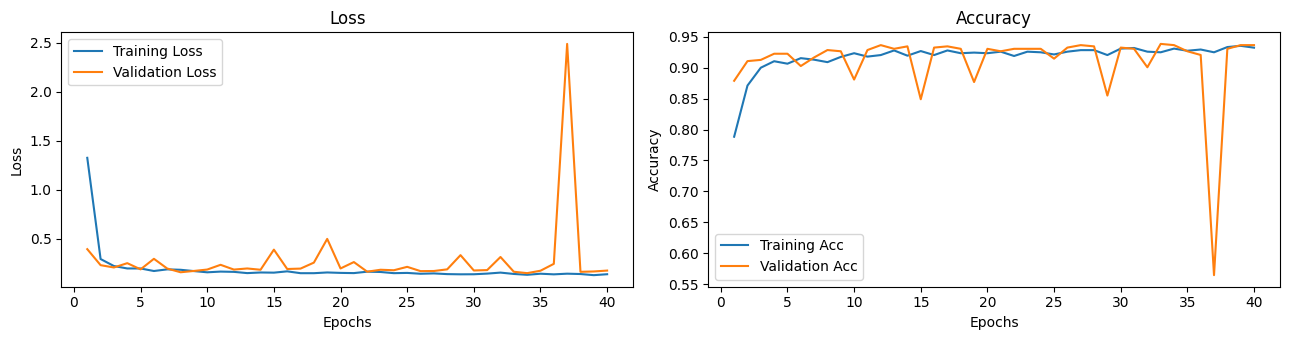

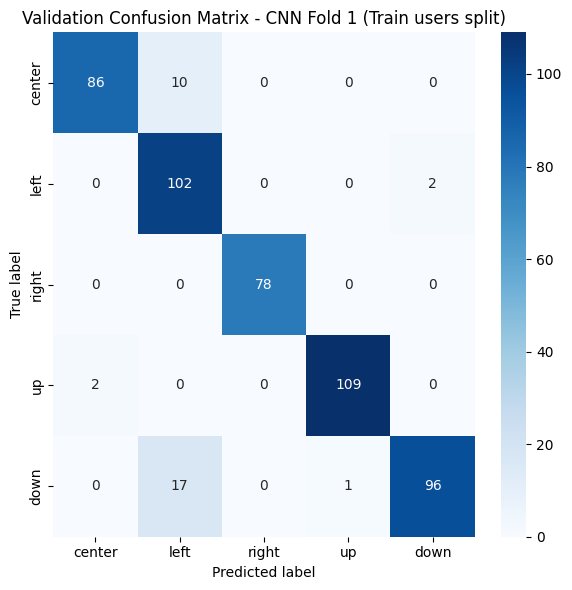


VALIDATION METRICS TABLE - CNN Fold 1
-------------------------------------
class         precision     recall   f1-score    support
--------------------------------------------------------
center             0.98       0.90       0.93         96
left               0.79       0.98       0.88        104
right              1.00       1.00       1.00         78
up                 0.99       0.98       0.99        111
down               0.98       0.84       0.91        114
macro avg          0.95       0.94       0.94        503
weighted avg       0.95       0.94       0.94        503
accuracy           0.94       0.94       0.94        503

FINAL TEST Accuracy - CNN Fold 1 (Held-out user3): 0.6707


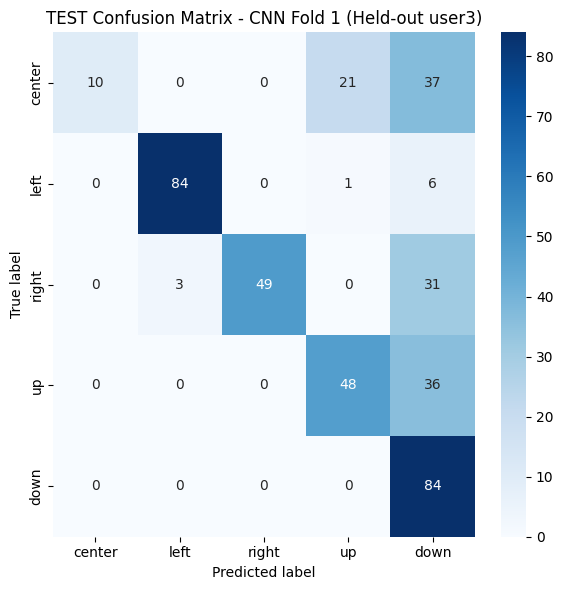


TEST METRICS TABLE - CNN Fold 1 (Held-out user3)
------------------------------------------------
class         precision     recall   f1-score    support
--------------------------------------------------------
center             1.00       0.15       0.26         68
left               0.97       0.92       0.94         91
right              1.00       0.59       0.74         83
up                 0.69       0.57       0.62         84
down               0.43       1.00       0.60         84
macro avg          0.82       0.65       0.63        410
weighted avg       0.81       0.67       0.65        410
accuracy           0.67       0.67       0.67        410

Saved:
 - Best CNN checkpoint: /content/drive/MyDrive/Heatmaps/cnn_saved_models/cnn_best_user3.pt
 - Plots/reports folder: /content/drive/MyDrive/Heatmaps/louo_cnn_results/user3_heldout


In [3]:
# ============================================================
# LOUO CNN (Fold 1): Train user2-5, Val split 80/20 on those 4 users,
# Test on unseen user1_test.npz
# Saves best model: saved_models/cnn_best_user1.pt
# ============================================================

import os, glob, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------
# CONFIG
DRIVE_ROOT = "/content/drive/MyDrive"
TRAIN_ROOT = os.path.join(DRIVE_ROOT, "Heatmaps", "New_train_heatmaps")
TEST_ROOT  = os.path.join(DRIVE_ROOT, "Heatmaps", "New_test_heatmaps")

FOLD = 1
ALL_USERS = ["user1", "user2", "user4", "user5"]
HELD_OUT_USER = "user3"
TRAIN_USERS = [u for u in ALL_USERS if u != HELD_OUT_USER]

NUM_CLASSES = 5
BATCH_SIZE = 32
EPOCHS = 40
LR = 5e-4
WEIGHT_DECAY = 1e-4
IMG_SIZE = 224

LABEL_MAP = {"center": 0, "left": 1, "right": 2, "up": 3, "down": 4}
LABELS = ["center", "left", "right", "up", "down"]

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Output folders
SAVE_DIR = os.path.join(DRIVE_ROOT, "Heatmaps", "louo_cnn_results", f"{HELD_OUT_USER}_heldout")
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_DIR = os.path.join(DRIVE_ROOT, "Heatmaps", "cnn_saved_models")
os.makedirs(MODEL_DIR, exist_ok=True)

print("Saving plots/results to:", SAVE_DIR)
print("Saving model checkpoints to:", MODEL_DIR)

# -----------------------
# NPZ loader for test file userX_test.npz
def load_npz_images_labels(path):
    d = np.load(path, allow_pickle=True)
    keys = d.files
    if "heatmaps" in keys and "labels" in keys:
        return d["heatmaps"], d["labels"]
    if "images" in keys and "labels" in keys:
        return d["images"], d["labels"]
    if "X" in keys and "y" in keys:
        return d["X"], d["y"]
    raise ValueError(f"Test NPZ format not recognized. Keys found: {keys}")

# Training-file loader (supports heatmaps/images/X + labels/y or infer from filename)
def find_data_and_labels(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    keys = d.files

    if "heatmaps" in keys:
        X = d["heatmaps"]
    elif "images" in keys:
        X = d["images"]
    elif "X" in keys:
        X = d["X"]
    else:
        X = d[keys[0]]

    if "labels" in keys:
        y = d["labels"]
    elif "y" in keys:
        y = d["y"]
    else:
        fname = os.path.basename(npz_path).lower()
        lab = None
        for name, idx in LABEL_MAP.items():
            if name in fname:
                lab = idx
                break
        if lab is None:
            raise ValueError(f"Cannot infer label from filename: {npz_path}")
        y = np.full((X.shape[0],), lab, dtype=np.int64)

    return X, y

# -----------------------
# Dataset for training users: root/user/*.npz (each frame is a sample)
class UserHeatmapDataset(Dataset):
    def __init__(self, root_dir, user_list, image_size=224):
        self.samples = []  # (npz_path, frame_idx, label)
        self.cache = {}
        self.image_size = image_size

        print(f"Scanning TRAIN users: {user_list}")
        for user in user_list:
            user_dir = os.path.join(root_dir, user)
            if not os.path.isdir(user_dir):
                print("Missing:", user_dir)
                continue

            for f in glob.glob(os.path.join(user_dir, "*.npz")):
                try:
                    X_f, y_f = find_data_and_labels(f)
                    if X_f.shape[0] == 0:
                        continue
                    for i in range(X_f.shape[0]):
                        self.samples.append((f, i, int(y_f[i])))
                except Exception:
                    pass

        print("Total samples (train users only):", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def _load_npz(self, npz_path):
        if npz_path not in self.cache:
            d = np.load(npz_path, allow_pickle=True)
            keys = d.files
            if "heatmaps" in keys:
                self.cache[npz_path] = d["heatmaps"]
            elif "images" in keys:
                self.cache[npz_path] = d["images"]
            elif "X" in keys:
                self.cache[npz_path] = d["X"]
            else:
                self.cache[npz_path] = d[keys[0]]
        return self.cache[npz_path]

    def __getitem__(self, idx):
        npz_path, frame_idx, label = self.samples[idx]
        arr = self._load_npz(npz_path)
        img = np.asarray(arr[frame_idx]).astype(np.float32)

        # Safety: if CHW -> HWC
        if img.ndim == 3 and img.shape[0] == 3 and img.shape[-1] != 3:
            img = np.transpose(img, (1, 2, 0))

        # Normalize per-image to 0..1 (kept consistent with your ResNet preprocessing)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # Ensure 3 channels
        if img.ndim == 2:
            img = np.stack([img, img, img], axis=-1)
        elif img.ndim == 3 and img.shape[-1] == 1:
            img = np.concatenate([img, img, img], axis=-1)

        x = torch.from_numpy(img).permute(2, 0, 1)  # C,H,W
        x = (x - 0.5) / 0.5

        x = F.interpolate(
            x.unsqueeze(0),
            size=(self.image_size, self.image_size),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        return x, int(label)

# Dataset for held-out test arrays in userX_test.npz
class HeatmapArrayDataset(Dataset):
    def __init__(self, images, labels, image_size=224):
        self.images = np.asarray(images)
        self.labels = np.asarray(labels).astype(np.int64)
        self.image_size = image_size

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        img = self.images[i].astype(np.float32)

        # Safety: if CHW -> HWC
        if img.ndim == 3 and img.shape[0] == 3 and img.shape[-1] != 3:
            img = np.transpose(img, (1, 2, 0))

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        if img.ndim == 2:
            img = np.stack([img, img, img], axis=-1)
        elif img.ndim == 3 and img.shape[-1] == 1:
            img = np.concatenate([img, img, img], axis=-1)

        x = torch.from_numpy(img).permute(2, 0, 1)
        x = (x - 0.5) / 0.5

        x = F.interpolate(
            x.unsqueeze(0),
            size=(self.image_size, self.image_size),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        return x, int(self.labels[i])

# -----------------------
# CNN ARCHITECTURE (EXACT)
class RobustCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4   = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(256 * 14 * 14, 512)  # 50176 -> 512
        self.drop = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)

# -----------------------
# Plot helpers (same style as ResNet outputs: Blues, PPT-friendly)
def plot_confusion(cm, title, save_path):
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
                xticklabels=LABELS, yticklabels=LABELS)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

def plot_curves(train_losses, val_losses, train_accs, val_accs, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

    axes[0].plot(range(1, len(train_losses)+1), train_losses, linestyle='-', color='tab:blue', label="Training Loss")
    axes[0].plot(range(1, len(val_losses)+1),   val_losses,   linestyle='-', color='tab:orange', label="Validation Loss")
    axes[0].set_xlabel("Epochs"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].set_title("Loss")

    axes[1].plot(range(1, len(train_accs)+1), train_accs, linestyle='-', color='tab:blue', label="Training Acc")
    axes[1].plot(range(1, len(val_accs)+1),   val_accs,   linestyle='-', color='tab:orange', label="Validation Acc")
    axes[1].set_xlabel("Epochs"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(); axes[1].set_title("Accuracy")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

def make_metrics_table(y_true, y_pred):
    p, r, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(NUM_CLASSES)), zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)

    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

    rows = []
    for i, lab in enumerate(LABELS):
        rows.append([lab, p[i], r[i], f1[i], int(sup[i])])
    rows.append(["macro avg", p_macro, r_macro, f1_macro, int(np.sum(sup))])
    rows.append(["weighted avg", p_w, r_w, f1_w, int(np.sum(sup))])
    rows.append(["accuracy", acc, acc, acc, int(np.sum(sup))])
    return rows

def print_metrics_table(rows, title):
    print("\n" + title)
    print("-" * len(title))
    header = f"{'class':<12} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>10}"
    print(header)
    print("-" * len(header))
    for cls, p, r, f1, sup in rows:
        print(f"{cls:<12} {p:>10.2f} {r:>10.2f} {f1:>10.2f} {sup:>10}")

# ============================================================
# 1) Build train dataset from 4 users (ALL samples) + 80/20 split
# ============================================================
full_train_dataset = UserHeatmapDataset(TRAIN_ROOT, TRAIN_USERS, image_size=IMG_SIZE)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_ds, val_ds = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train/Val samples (train users only): {train_size}/{val_size}")

# ============================================================
# 2) Load held-out test user1_test.npz
# ============================================================
test_path = os.path.join(TEST_ROOT, f"{HELD_OUT_USER}_test.npz")
test_imgs, test_labels = load_npz_images_labels(test_path)
test_ds = HeatmapArrayDataset(test_imgs, test_labels, image_size=IMG_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print("Test samples (held-out user):", len(test_ds))

# ============================================================
# 3) Train CNN (exact config)
# ============================================================
model = RobustCNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0
best_ckpt_path = os.path.join(MODEL_DIR, f"cnn_best_{HELD_OUT_USER}.pt")  # <-- saves per user

for epoch in range(1, EPOCHS + 1):
    # ---- Train ----
    model.train()
    correct, total, loss_sum = 0, 0, 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device).float(), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * xb.size(0)
        pred = out.argmax(1)
        correct += (pred == yb).sum().item()
        total += xb.size(0)

    tr_loss = loss_sum / total
    tr_acc = correct / total

    # ---- Val ----
    model.eval()
    v_correct, v_total, v_loss_sum = 0, 0, 0.0
    val_preds, val_true = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device).float(), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)

            v_loss_sum += loss.item() * xb.size(0)
            pred = out.argmax(1)

            v_correct += (pred == yb).sum().item()
            v_total += xb.size(0)

            val_preds.append(pred.cpu().numpy())
            val_true.append(yb.cpu().numpy())

    v_loss = v_loss_sum / v_total
    v_acc = v_correct / v_total

    train_losses.append(tr_loss)
    val_losses.append(v_loss)
    train_accs.append(tr_acc)
    val_accs.append(v_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
          f"Val Loss {v_loss:.4f} Acc {v_acc:.4f}")

    # Save BEST checkpoint by val accuracy
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save({
            "model_type": "RobustCNN",
            "held_out_user": HELD_OUT_USER,
            "img_size": IMG_SIZE,
            "label_map": LABEL_MAP,
            "state_dict": model.state_dict(),
            "best_val_acc": float(best_val_acc),
        }, best_ckpt_path)

# ============================================================
# 4) Curves + VALIDATION confusion matrix + metrics table
# ============================================================
plot_curves(
    train_losses, val_losses, train_accs, val_accs,
    save_path=os.path.join(SAVE_DIR, f"loss_acc_curves_fold{FOLD}.png")
)

val_preds = np.concatenate(val_preds)
val_true  = np.concatenate(val_true)

cm_val = confusion_matrix(val_true, val_preds, labels=list(range(NUM_CLASSES)))
plot_confusion(
    cm_val,
    title=f"Validation Confusion Matrix - CNN Fold {FOLD} (Train users split)",
    save_path=os.path.join(SAVE_DIR, f"val_confusion_matrix_fold{FOLD}.png")
)

val_rows = make_metrics_table(val_true, val_preds)
print_metrics_table(val_rows, title=f"VALIDATION METRICS TABLE - CNN Fold {FOLD}")

with open(os.path.join(SAVE_DIR, f"val_classification_report_fold{FOLD}.txt"), "w") as f:
    f.write(classification_report(val_true, val_preds, target_names=LABELS, zero_division=0))

# ============================================================
# 5) FINAL TEST on held-out user1 + confusion matrix + metrics table
# ============================================================
ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt["state_dict"])
model.eval()

test_preds, test_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device).float()
        out = model(xb)
        pred = out.argmax(1)
        test_preds.append(pred.cpu().numpy())
        test_true.append(np.asarray(yb))

test_preds = np.concatenate(test_preds)
test_true  = np.concatenate(test_true)

test_acc = (test_preds == test_true).mean() if len(test_true) else 0.0
print(f"\nFINAL TEST Accuracy - CNN Fold {FOLD} (Held-out {HELD_OUT_USER}): {test_acc:.4f}")

cm_test = confusion_matrix(test_true, test_preds, labels=list(range(NUM_CLASSES)))
plot_confusion(
    cm_test,
    title=f"TEST Confusion Matrix - CNN Fold {FOLD} (Held-out {HELD_OUT_USER})",
    save_path=os.path.join(SAVE_DIR, f"test_confusion_matrix_fold{FOLD}.png")
)

test_rows = make_metrics_table(test_true, test_preds)
print_metrics_table(test_rows, title=f"TEST METRICS TABLE - CNN Fold {FOLD} (Held-out {HELD_OUT_USER})")

with open(os.path.join(SAVE_DIR, f"test_classification_report_fold{FOLD}.txt"), "w") as f:
    f.write(classification_report(test_true, test_preds, target_names=LABELS, zero_division=0))

print("\nSaved:")
print(" - Best CNN checkpoint:", best_ckpt_path)
print(" - Plots/reports folder:", SAVE_DIR)


Held out User - user 4

Device: cuda
Saving plots/results to: /content/drive/MyDrive/Heatmaps/louo_cnn_results/user4_heldout
Saving model checkpoints to: /content/drive/MyDrive/Heatmaps/cnn_saved_models
Scanning TRAIN users: ['user1', 'user2', 'user3', 'user5']
Total samples (train users only): 2513
Train/Val samples (train users only): 2010/503
Test samples (held-out user): 455
Epoch 01/40 | Train Loss 0.8147 Acc 0.8637 | Val Loss 0.1050 Acc 0.9622
Epoch 02/40 | Train Loss 0.2480 Acc 0.9234 | Val Loss 0.1352 Acc 0.9463
Epoch 03/40 | Train Loss 0.1729 Acc 0.9323 | Val Loss 0.0575 Acc 0.9722
Epoch 04/40 | Train Loss 0.1205 Acc 0.9517 | Val Loss 0.0614 Acc 0.9742
Epoch 05/40 | Train Loss 0.1253 Acc 0.9507 | Val Loss 0.0428 Acc 0.9682
Epoch 06/40 | Train Loss 0.1018 Acc 0.9522 | Val Loss 0.0856 Acc 0.9602
Epoch 07/40 | Train Loss 0.1062 Acc 0.9562 | Val Loss 0.0706 Acc 0.9682
Epoch 08/40 | Train Loss 0.0901 Acc 0.9552 | Val Loss 0.0602 Acc 0.9742
Epoch 09/40 | Train Loss 0.0728 Acc 0.9637 | Val Loss 0.0465 Acc 0

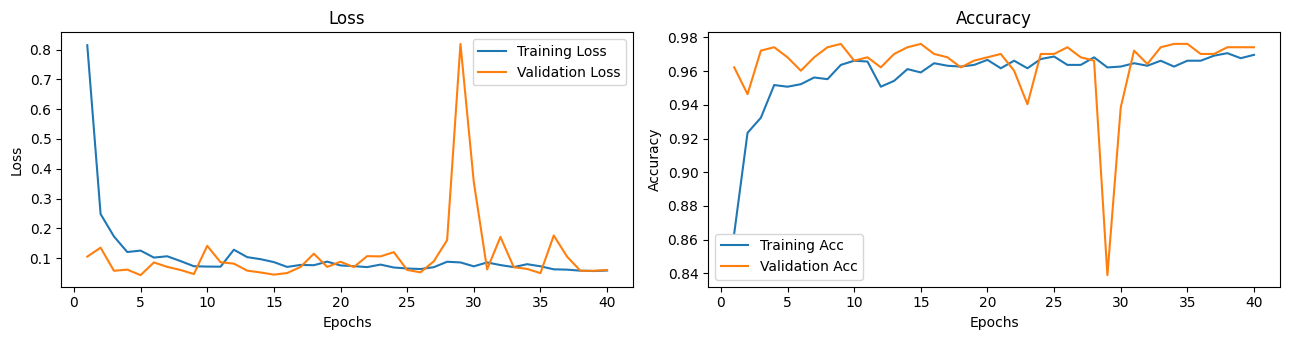

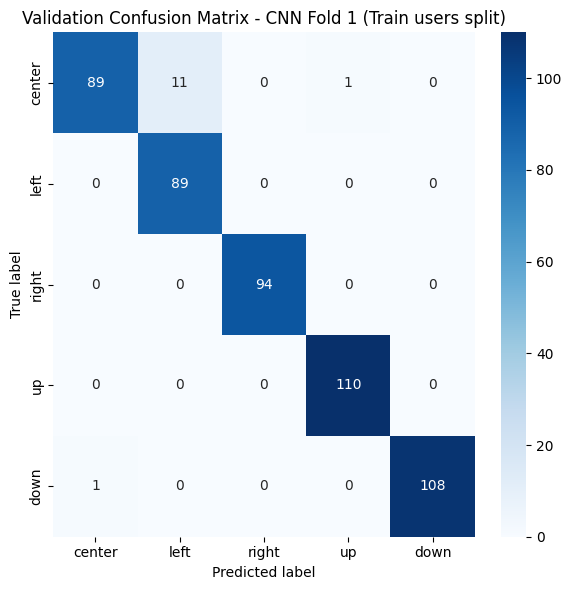


VALIDATION METRICS TABLE - CNN Fold 1
-------------------------------------
class         precision     recall   f1-score    support
--------------------------------------------------------
center             0.99       0.88       0.93        101
left               0.89       1.00       0.94         89
right              1.00       1.00       1.00         94
up                 0.99       1.00       1.00        110
down               1.00       0.99       1.00        109
macro avg          0.97       0.97       0.97        503
weighted avg       0.98       0.97       0.97        503
accuracy           0.97       0.97       0.97        503

FINAL TEST Accuracy - CNN Fold 1 (Held-out user4): 0.4725


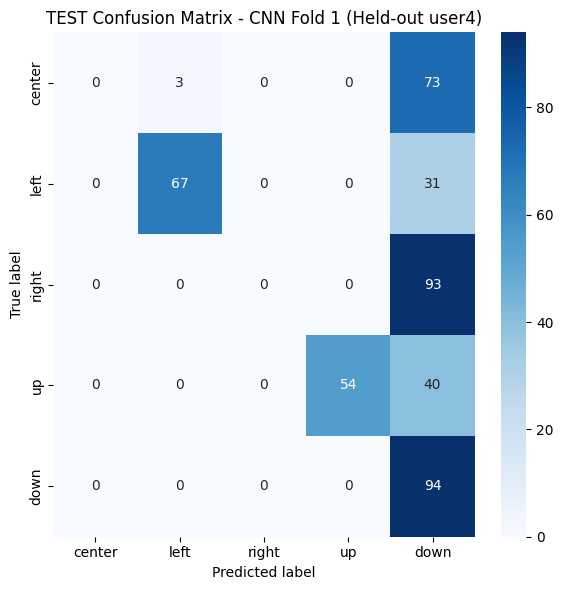


TEST METRICS TABLE - CNN Fold 1 (Held-out user4)
------------------------------------------------
class         precision     recall   f1-score    support
--------------------------------------------------------
center             0.00       0.00       0.00         76
left               0.96       0.68       0.80         98
right              0.00       0.00       0.00         93
up                 1.00       0.57       0.73         94
down               0.28       1.00       0.44         94
macro avg          0.45       0.45       0.39        455
weighted avg       0.47       0.47       0.41        455
accuracy           0.47       0.47       0.47        455

Saved:
 - Best CNN checkpoint: /content/drive/MyDrive/Heatmaps/cnn_saved_models/cnn_best_user4.pt
 - Plots/reports folder: /content/drive/MyDrive/Heatmaps/louo_cnn_results/user4_heldout


In [4]:
# ============================================================
# LOUO CNN (Fold 1): Train user2-5, Val split 80/20 on those 4 users,
# Test on unseen user1_test.npz
# Saves best model: saved_models/cnn_best_user1.pt
# ============================================================

import os, glob, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------
# CONFIG
DRIVE_ROOT = "/content/drive/MyDrive"
TRAIN_ROOT = os.path.join(DRIVE_ROOT, "Heatmaps", "New_train_heatmaps")
TEST_ROOT  = os.path.join(DRIVE_ROOT, "Heatmaps", "New_test_heatmaps")

FOLD = 1
ALL_USERS = ["user1", "user2", "user3", "user5"]
HELD_OUT_USER = "user4"
TRAIN_USERS = [u for u in ALL_USERS if u != HELD_OUT_USER]

NUM_CLASSES = 5
BATCH_SIZE = 32
EPOCHS = 40
LR = 5e-4
WEIGHT_DECAY = 1e-4
IMG_SIZE = 224

LABEL_MAP = {"center": 0, "left": 1, "right": 2, "up": 3, "down": 4}
LABELS = ["center", "left", "right", "up", "down"]

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Output folders
SAVE_DIR = os.path.join(DRIVE_ROOT, "Heatmaps", "louo_cnn_results", f"{HELD_OUT_USER}_heldout")
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_DIR = os.path.join(DRIVE_ROOT, "Heatmaps", "cnn_saved_models")
os.makedirs(MODEL_DIR, exist_ok=True)

print("Saving plots/results to:", SAVE_DIR)
print("Saving model checkpoints to:", MODEL_DIR)

# -----------------------
# NPZ loader for test file userX_test.npz
def load_npz_images_labels(path):
    d = np.load(path, allow_pickle=True)
    keys = d.files
    if "heatmaps" in keys and "labels" in keys:
        return d["heatmaps"], d["labels"]
    if "images" in keys and "labels" in keys:
        return d["images"], d["labels"]
    if "X" in keys and "y" in keys:
        return d["X"], d["y"]
    raise ValueError(f"Test NPZ format not recognized. Keys found: {keys}")

# Training-file loader (supports heatmaps/images/X + labels/y or infer from filename)
def find_data_and_labels(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    keys = d.files

    if "heatmaps" in keys:
        X = d["heatmaps"]
    elif "images" in keys:
        X = d["images"]
    elif "X" in keys:
        X = d["X"]
    else:
        X = d[keys[0]]

    if "labels" in keys:
        y = d["labels"]
    elif "y" in keys:
        y = d["y"]
    else:
        fname = os.path.basename(npz_path).lower()
        lab = None
        for name, idx in LABEL_MAP.items():
            if name in fname:
                lab = idx
                break
        if lab is None:
            raise ValueError(f"Cannot infer label from filename: {npz_path}")
        y = np.full((X.shape[0],), lab, dtype=np.int64)

    return X, y

# -----------------------
# Dataset for training users: root/user/*.npz (each frame is a sample)
class UserHeatmapDataset(Dataset):
    def __init__(self, root_dir, user_list, image_size=224):
        self.samples = []  # (npz_path, frame_idx, label)
        self.cache = {}
        self.image_size = image_size

        print(f"Scanning TRAIN users: {user_list}")
        for user in user_list:
            user_dir = os.path.join(root_dir, user)
            if not os.path.isdir(user_dir):
                print("Missing:", user_dir)
                continue

            for f in glob.glob(os.path.join(user_dir, "*.npz")):
                try:
                    X_f, y_f = find_data_and_labels(f)
                    if X_f.shape[0] == 0:
                        continue
                    for i in range(X_f.shape[0]):
                        self.samples.append((f, i, int(y_f[i])))
                except Exception:
                    pass

        print("Total samples (train users only):", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def _load_npz(self, npz_path):
        if npz_path not in self.cache:
            d = np.load(npz_path, allow_pickle=True)
            keys = d.files
            if "heatmaps" in keys:
                self.cache[npz_path] = d["heatmaps"]
            elif "images" in keys:
                self.cache[npz_path] = d["images"]
            elif "X" in keys:
                self.cache[npz_path] = d["X"]
            else:
                self.cache[npz_path] = d[keys[0]]
        return self.cache[npz_path]

    def __getitem__(self, idx):
        npz_path, frame_idx, label = self.samples[idx]
        arr = self._load_npz(npz_path)
        img = np.asarray(arr[frame_idx]).astype(np.float32)

        # Safety: if CHW -> HWC
        if img.ndim == 3 and img.shape[0] == 3 and img.shape[-1] != 3:
            img = np.transpose(img, (1, 2, 0))

        # Normalize per-image to 0..1 (kept consistent with your ResNet preprocessing)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # Ensure 3 channels
        if img.ndim == 2:
            img = np.stack([img, img, img], axis=-1)
        elif img.ndim == 3 and img.shape[-1] == 1:
            img = np.concatenate([img, img, img], axis=-1)

        x = torch.from_numpy(img).permute(2, 0, 1)  # C,H,W
        x = (x - 0.5) / 0.5

        x = F.interpolate(
            x.unsqueeze(0),
            size=(self.image_size, self.image_size),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        return x, int(label)

# Dataset for held-out test arrays in userX_test.npz
class HeatmapArrayDataset(Dataset):
    def __init__(self, images, labels, image_size=224):
        self.images = np.asarray(images)
        self.labels = np.asarray(labels).astype(np.int64)
        self.image_size = image_size

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        img = self.images[i].astype(np.float32)

        # Safety: if CHW -> HWC
        if img.ndim == 3 and img.shape[0] == 3 and img.shape[-1] != 3:
            img = np.transpose(img, (1, 2, 0))

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        if img.ndim == 2:
            img = np.stack([img, img, img], axis=-1)
        elif img.ndim == 3 and img.shape[-1] == 1:
            img = np.concatenate([img, img, img], axis=-1)

        x = torch.from_numpy(img).permute(2, 0, 1)
        x = (x - 0.5) / 0.5

        x = F.interpolate(
            x.unsqueeze(0),
            size=(self.image_size, self.image_size),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        return x, int(self.labels[i])

# -----------------------
# CNN ARCHITECTURE (EXACT)
class RobustCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4   = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(256 * 14 * 14, 512)  # 50176 -> 512
        self.drop = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)

# -----------------------
# Plot helpers (same style as ResNet outputs: Blues, PPT-friendly)
def plot_confusion(cm, title, save_path):
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
                xticklabels=LABELS, yticklabels=LABELS)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

def plot_curves(train_losses, val_losses, train_accs, val_accs, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

    axes[0].plot(range(1, len(train_losses)+1), train_losses, linestyle='-', color='tab:blue', label="Training Loss")
    axes[0].plot(range(1, len(val_losses)+1),   val_losses,   linestyle='-', color='tab:orange', label="Validation Loss")
    axes[0].set_xlabel("Epochs"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].set_title("Loss")

    axes[1].plot(range(1, len(train_accs)+1), train_accs, linestyle='-', color='tab:blue', label="Training Acc")
    axes[1].plot(range(1, len(val_accs)+1),   val_accs,   linestyle='-', color='tab:orange', label="Validation Acc")
    axes[1].set_xlabel("Epochs"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(); axes[1].set_title("Accuracy")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

def make_metrics_table(y_true, y_pred):
    p, r, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(NUM_CLASSES)), zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)

    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

    rows = []
    for i, lab in enumerate(LABELS):
        rows.append([lab, p[i], r[i], f1[i], int(sup[i])])
    rows.append(["macro avg", p_macro, r_macro, f1_macro, int(np.sum(sup))])
    rows.append(["weighted avg", p_w, r_w, f1_w, int(np.sum(sup))])
    rows.append(["accuracy", acc, acc, acc, int(np.sum(sup))])
    return rows

def print_metrics_table(rows, title):
    print("\n" + title)
    print("-" * len(title))
    header = f"{'class':<12} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>10}"
    print(header)
    print("-" * len(header))
    for cls, p, r, f1, sup in rows:
        print(f"{cls:<12} {p:>10.2f} {r:>10.2f} {f1:>10.2f} {sup:>10}")

# ============================================================
# 1) Build train dataset from 4 users (ALL samples) + 80/20 split
# ============================================================
full_train_dataset = UserHeatmapDataset(TRAIN_ROOT, TRAIN_USERS, image_size=IMG_SIZE)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_ds, val_ds = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train/Val samples (train users only): {train_size}/{val_size}")

# ============================================================
# 2) Load held-out test user1_test.npz
# ============================================================
test_path = os.path.join(TEST_ROOT, f"{HELD_OUT_USER}_test.npz")
test_imgs, test_labels = load_npz_images_labels(test_path)
test_ds = HeatmapArrayDataset(test_imgs, test_labels, image_size=IMG_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print("Test samples (held-out user):", len(test_ds))

# ============================================================
# 3) Train CNN (exact config)
# ============================================================
model = RobustCNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0
best_ckpt_path = os.path.join(MODEL_DIR, f"cnn_best_{HELD_OUT_USER}.pt")  # <-- saves per user

for epoch in range(1, EPOCHS + 1):
    # ---- Train ----
    model.train()
    correct, total, loss_sum = 0, 0, 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device).float(), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * xb.size(0)
        pred = out.argmax(1)
        correct += (pred == yb).sum().item()
        total += xb.size(0)

    tr_loss = loss_sum / total
    tr_acc = correct / total

    # ---- Val ----
    model.eval()
    v_correct, v_total, v_loss_sum = 0, 0, 0.0
    val_preds, val_true = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device).float(), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)

            v_loss_sum += loss.item() * xb.size(0)
            pred = out.argmax(1)

            v_correct += (pred == yb).sum().item()
            v_total += xb.size(0)

            val_preds.append(pred.cpu().numpy())
            val_true.append(yb.cpu().numpy())

    v_loss = v_loss_sum / v_total
    v_acc = v_correct / v_total

    train_losses.append(tr_loss)
    val_losses.append(v_loss)
    train_accs.append(tr_acc)
    val_accs.append(v_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
          f"Val Loss {v_loss:.4f} Acc {v_acc:.4f}")

    # Save BEST checkpoint by val accuracy
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save({
            "model_type": "RobustCNN",
            "held_out_user": HELD_OUT_USER,
            "img_size": IMG_SIZE,
            "label_map": LABEL_MAP,
            "state_dict": model.state_dict(),
            "best_val_acc": float(best_val_acc),
        }, best_ckpt_path)

# ============================================================
# 4) Curves + VALIDATION confusion matrix + metrics table
# ============================================================
plot_curves(
    train_losses, val_losses, train_accs, val_accs,
    save_path=os.path.join(SAVE_DIR, f"loss_acc_curves_fold{FOLD}.png")
)

val_preds = np.concatenate(val_preds)
val_true  = np.concatenate(val_true)

cm_val = confusion_matrix(val_true, val_preds, labels=list(range(NUM_CLASSES)))
plot_confusion(
    cm_val,
    title=f"Validation Confusion Matrix - CNN Fold {FOLD} (Train users split)",
    save_path=os.path.join(SAVE_DIR, f"val_confusion_matrix_fold{FOLD}.png")
)

val_rows = make_metrics_table(val_true, val_preds)
print_metrics_table(val_rows, title=f"VALIDATION METRICS TABLE - CNN Fold {FOLD}")

with open(os.path.join(SAVE_DIR, f"val_classification_report_fold{FOLD}.txt"), "w") as f:
    f.write(classification_report(val_true, val_preds, target_names=LABELS, zero_division=0))

# ============================================================
# 5) FINAL TEST on held-out user1 + confusion matrix + metrics table
# ============================================================
ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt["state_dict"])
model.eval()

test_preds, test_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device).float()
        out = model(xb)
        pred = out.argmax(1)
        test_preds.append(pred.cpu().numpy())
        test_true.append(np.asarray(yb))

test_preds = np.concatenate(test_preds)
test_true  = np.concatenate(test_true)

test_acc = (test_preds == test_true).mean() if len(test_true) else 0.0
print(f"\nFINAL TEST Accuracy - CNN Fold {FOLD} (Held-out {HELD_OUT_USER}): {test_acc:.4f}")

cm_test = confusion_matrix(test_true, test_preds, labels=list(range(NUM_CLASSES)))
plot_confusion(
    cm_test,
    title=f"TEST Confusion Matrix - CNN Fold {FOLD} (Held-out {HELD_OUT_USER})",
    save_path=os.path.join(SAVE_DIR, f"test_confusion_matrix_fold{FOLD}.png")
)

test_rows = make_metrics_table(test_true, test_preds)
print_metrics_table(test_rows, title=f"TEST METRICS TABLE - CNN Fold {FOLD} (Held-out {HELD_OUT_USER})")

with open(os.path.join(SAVE_DIR, f"test_classification_report_fold{FOLD}.txt"), "w") as f:
    f.write(classification_report(test_true, test_preds, target_names=LABELS, zero_division=0))

print("\nSaved:")
print(" - Best CNN checkpoint:", best_ckpt_path)
print(" - Plots/reports folder:", SAVE_DIR)


Device: cuda
Saving plots/results to: /content/drive/MyDrive/Heatmaps/louo_cnn_results/user5_heldout
Saving model checkpoints to: /content/drive/MyDrive/Heatmaps/cnn_saved_models
Scanning TRAIN users: ['user1', 'user2', 'user3', 'user4']
Total samples (train users only): 2500
Train/Val samples (train users only): 2000/500
Test samples (held-out user): 407
Epoch 01/40 | Train Loss 1.0606 Acc 0.8420 | Val Loss 0.2777 Acc 0.9200
Epoch 02/40 | Train Loss 0.2841 Acc 0.9070 | Val Loss 0.2649 Acc 0.8880
Epoch 03/40 | Train Loss 0.2212 Acc 0.9185 | Val Loss 0.1923 Acc 0.9480
Epoch 04/40 | Train Loss 0.1776 Acc 0.9270 | Val Loss 0.2012 Acc 0.9280
Epoch 05/40 | Train Loss 0.1655 Acc 0.9350 | Val Loss 0.1548 Acc 0.9380
Epoch 06/40 | Train Loss 0.1429 Acc 0.9415 | Val Loss 0.1857 Acc 0.9160
Epoch 07/40 | Train Loss 0.1422 Acc 0.9370 | Val Loss 0.4374 Acc 0.8760
Epoch 08/40 | Train Loss 0.1561 Acc 0.9410 | Val Loss 0.1562 Acc 0.9380
Epoch 09/40 | Train Loss 0.1325 Acc 0.9415 | Val Loss 0.2570 Acc 0

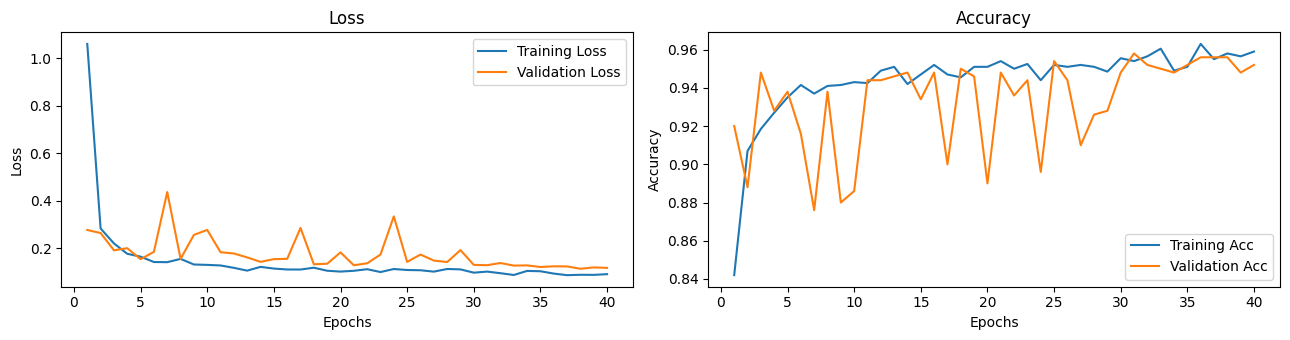

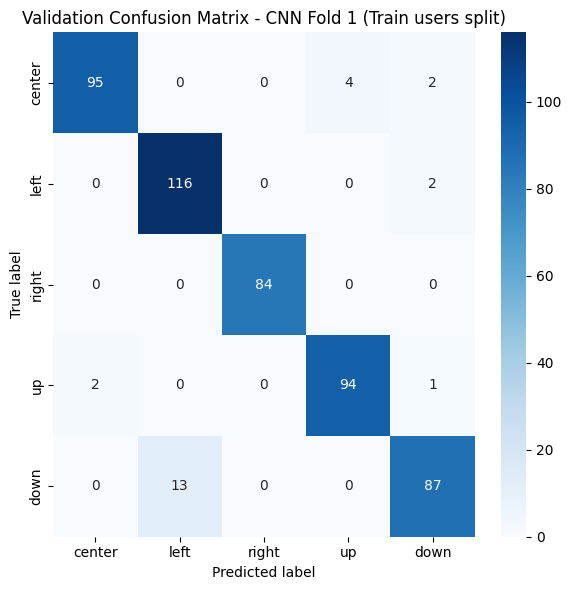


VALIDATION METRICS TABLE - CNN Fold 1
-------------------------------------
class         precision     recall   f1-score    support
--------------------------------------------------------
center             0.98       0.94       0.96        101
left               0.90       0.98       0.94        118
right              1.00       1.00       1.00         84
up                 0.96       0.97       0.96         97
down               0.95       0.87       0.91        100
macro avg          0.96       0.95       0.95        500
weighted avg       0.95       0.95       0.95        500
accuracy           0.95       0.95       0.95        500

FINAL TEST Accuracy - CNN Fold 1 (Held-out user5): 0.3882


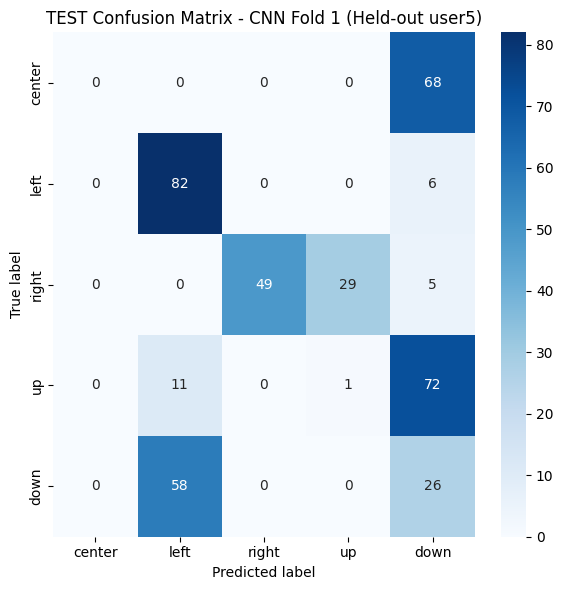


TEST METRICS TABLE - CNN Fold 1 (Held-out user5)
------------------------------------------------
class         precision     recall   f1-score    support
--------------------------------------------------------
center             0.00       0.00       0.00         68
left               0.54       0.93       0.69         88
right              1.00       0.59       0.74         83
up                 0.03       0.01       0.02         84
down               0.15       0.31       0.20         84
macro avg          0.34       0.37       0.33        407
weighted avg       0.36       0.39       0.34        407
accuracy           0.39       0.39       0.39        407

Saved:
 - Best CNN checkpoint: /content/drive/MyDrive/Heatmaps/cnn_saved_models/cnn_best_user5.pt
 - Plots/reports folder: /content/drive/MyDrive/Heatmaps/louo_cnn_results/user5_heldout


In [5]:
# ============================================================
# LOUO CNN (Fold 1): Train user2-5, Val split 80/20 on those 4 users,
# Test on unseen user1_test.npz
# Saves best model: saved_models/cnn_best_user1.pt
# ============================================================

import os, glob, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------
# CONFIG
DRIVE_ROOT = "/content/drive/MyDrive"
TRAIN_ROOT = os.path.join(DRIVE_ROOT, "Heatmaps", "New_train_heatmaps")
TEST_ROOT  = os.path.join(DRIVE_ROOT, "Heatmaps", "New_test_heatmaps")

FOLD = 1
ALL_USERS = ["user1", "user2", "user3", "user4"]
HELD_OUT_USER = "user5"
TRAIN_USERS = [u for u in ALL_USERS if u != HELD_OUT_USER]

NUM_CLASSES = 5
BATCH_SIZE = 32
EPOCHS = 40
LR = 5e-4
WEIGHT_DECAY = 1e-4
IMG_SIZE = 224

LABEL_MAP = {"center": 0, "left": 1, "right": 2, "up": 3, "down": 4}
LABELS = ["center", "left", "right", "up", "down"]

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Output folders
SAVE_DIR = os.path.join(DRIVE_ROOT, "Heatmaps", "louo_cnn_results", f"{HELD_OUT_USER}_heldout")
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_DIR = os.path.join(DRIVE_ROOT, "Heatmaps", "cnn_saved_models")
os.makedirs(MODEL_DIR, exist_ok=True)

print("Saving plots/results to:", SAVE_DIR)
print("Saving model checkpoints to:", MODEL_DIR)

# -----------------------
# NPZ loader for test file userX_test.npz
def load_npz_images_labels(path):
    d = np.load(path, allow_pickle=True)
    keys = d.files
    if "heatmaps" in keys and "labels" in keys:
        return d["heatmaps"], d["labels"]
    if "images" in keys and "labels" in keys:
        return d["images"], d["labels"]
    if "X" in keys and "y" in keys:
        return d["X"], d["y"]
    raise ValueError(f"Test NPZ format not recognized. Keys found: {keys}")

# Training-file loader (supports heatmaps/images/X + labels/y or infer from filename)
def find_data_and_labels(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    keys = d.files

    if "heatmaps" in keys:
        X = d["heatmaps"]
    elif "images" in keys:
        X = d["images"]
    elif "X" in keys:
        X = d["X"]
    else:
        X = d[keys[0]]

    if "labels" in keys:
        y = d["labels"]
    elif "y" in keys:
        y = d["y"]
    else:
        fname = os.path.basename(npz_path).lower()
        lab = None
        for name, idx in LABEL_MAP.items():
            if name in fname:
                lab = idx
                break
        if lab is None:
            raise ValueError(f"Cannot infer label from filename: {npz_path}")
        y = np.full((X.shape[0],), lab, dtype=np.int64)

    return X, y

# -----------------------
# Dataset for training users: root/user/*.npz (each frame is a sample)
class UserHeatmapDataset(Dataset):
    def __init__(self, root_dir, user_list, image_size=224):
        self.samples = []  # (npz_path, frame_idx, label)
        self.cache = {}
        self.image_size = image_size

        print(f"Scanning TRAIN users: {user_list}")
        for user in user_list:
            user_dir = os.path.join(root_dir, user)
            if not os.path.isdir(user_dir):
                print("Missing:", user_dir)
                continue

            for f in glob.glob(os.path.join(user_dir, "*.npz")):
                try:
                    X_f, y_f = find_data_and_labels(f)
                    if X_f.shape[0] == 0:
                        continue
                    for i in range(X_f.shape[0]):
                        self.samples.append((f, i, int(y_f[i])))
                except Exception:
                    pass

        print("Total samples (train users only):", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def _load_npz(self, npz_path):
        if npz_path not in self.cache:
            d = np.load(npz_path, allow_pickle=True)
            keys = d.files
            if "heatmaps" in keys:
                self.cache[npz_path] = d["heatmaps"]
            elif "images" in keys:
                self.cache[npz_path] = d["images"]
            elif "X" in keys:
                self.cache[npz_path] = d["X"]
            else:
                self.cache[npz_path] = d[keys[0]]
        return self.cache[npz_path]

    def __getitem__(self, idx):
        npz_path, frame_idx, label = self.samples[idx]
        arr = self._load_npz(npz_path)
        img = np.asarray(arr[frame_idx]).astype(np.float32)

        # Safety: if CHW -> HWC
        if img.ndim == 3 and img.shape[0] == 3 and img.shape[-1] != 3:
            img = np.transpose(img, (1, 2, 0))

        # Normalize per-image to 0..1 (kept consistent with your ResNet preprocessing)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # Ensure 3 channels
        if img.ndim == 2:
            img = np.stack([img, img, img], axis=-1)
        elif img.ndim == 3 and img.shape[-1] == 1:
            img = np.concatenate([img, img, img], axis=-1)

        x = torch.from_numpy(img).permute(2, 0, 1)  # C,H,W
        x = (x - 0.5) / 0.5

        x = F.interpolate(
            x.unsqueeze(0),
            size=(self.image_size, self.image_size),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        return x, int(label)

# Dataset for held-out test arrays in userX_test.npz
class HeatmapArrayDataset(Dataset):
    def __init__(self, images, labels, image_size=224):
        self.images = np.asarray(images)
        self.labels = np.asarray(labels).astype(np.int64)
        self.image_size = image_size

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        img = self.images[i].astype(np.float32)

        # Safety: if CHW -> HWC
        if img.ndim == 3 and img.shape[0] == 3 and img.shape[-1] != 3:
            img = np.transpose(img, (1, 2, 0))

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        if img.ndim == 2:
            img = np.stack([img, img, img], axis=-1)
        elif img.ndim == 3 and img.shape[-1] == 1:
            img = np.concatenate([img, img, img], axis=-1)

        x = torch.from_numpy(img).permute(2, 0, 1)
        x = (x - 0.5) / 0.5

        x = F.interpolate(
            x.unsqueeze(0),
            size=(self.image_size, self.image_size),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        return x, int(self.labels[i])

# -----------------------
# CNN ARCHITECTURE (EXACT)
class RobustCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4   = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(256 * 14 * 14, 512)  # 50176 -> 512
        self.drop = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)

# -----------------------
# Plot helpers (same style as ResNet outputs: Blues, PPT-friendly)
def plot_confusion(cm, title, save_path):
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
                xticklabels=LABELS, yticklabels=LABELS)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

def plot_curves(train_losses, val_losses, train_accs, val_accs, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

    axes[0].plot(range(1, len(train_losses)+1), train_losses, linestyle='-', color='tab:blue', label="Training Loss")
    axes[0].plot(range(1, len(val_losses)+1),   val_losses,   linestyle='-', color='tab:orange', label="Validation Loss")
    axes[0].set_xlabel("Epochs"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].set_title("Loss")

    axes[1].plot(range(1, len(train_accs)+1), train_accs, linestyle='-', color='tab:blue', label="Training Acc")
    axes[1].plot(range(1, len(val_accs)+1),   val_accs,   linestyle='-', color='tab:orange', label="Validation Acc")
    axes[1].set_xlabel("Epochs"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(); axes[1].set_title("Accuracy")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

def make_metrics_table(y_true, y_pred):
    p, r, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(NUM_CLASSES)), zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)

    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

    rows = []
    for i, lab in enumerate(LABELS):
        rows.append([lab, p[i], r[i], f1[i], int(sup[i])])
    rows.append(["macro avg", p_macro, r_macro, f1_macro, int(np.sum(sup))])
    rows.append(["weighted avg", p_w, r_w, f1_w, int(np.sum(sup))])
    rows.append(["accuracy", acc, acc, acc, int(np.sum(sup))])
    return rows

def print_metrics_table(rows, title):
    print("\n" + title)
    print("-" * len(title))
    header = f"{'class':<12} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>10}"
    print(header)
    print("-" * len(header))
    for cls, p, r, f1, sup in rows:
        print(f"{cls:<12} {p:>10.2f} {r:>10.2f} {f1:>10.2f} {sup:>10}")

# ============================================================
# 1) Build train dataset from 4 users (ALL samples) + 80/20 split
# ============================================================
full_train_dataset = UserHeatmapDataset(TRAIN_ROOT, TRAIN_USERS, image_size=IMG_SIZE)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_ds, val_ds = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train/Val samples (train users only): {train_size}/{val_size}")

# ============================================================
# 2) Load held-out test user1_test.npz
# ============================================================
test_path = os.path.join(TEST_ROOT, f"{HELD_OUT_USER}_test.npz")
test_imgs, test_labels = load_npz_images_labels(test_path)
test_ds = HeatmapArrayDataset(test_imgs, test_labels, image_size=IMG_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print("Test samples (held-out user):", len(test_ds))

# ============================================================
# 3) Train CNN (exact config)
# ============================================================
model = RobustCNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0
best_ckpt_path = os.path.join(MODEL_DIR, f"cnn_best_{HELD_OUT_USER}.pt")  # <-- saves per user

for epoch in range(1, EPOCHS + 1):
    # ---- Train ----
    model.train()
    correct, total, loss_sum = 0, 0, 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device).float(), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * xb.size(0)
        pred = out.argmax(1)
        correct += (pred == yb).sum().item()
        total += xb.size(0)

    tr_loss = loss_sum / total
    tr_acc = correct / total

    # ---- Val ----
    model.eval()
    v_correct, v_total, v_loss_sum = 0, 0, 0.0
    val_preds, val_true = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device).float(), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)

            v_loss_sum += loss.item() * xb.size(0)
            pred = out.argmax(1)

            v_correct += (pred == yb).sum().item()
            v_total += xb.size(0)

            val_preds.append(pred.cpu().numpy())
            val_true.append(yb.cpu().numpy())

    v_loss = v_loss_sum / v_total
    v_acc = v_correct / v_total

    train_losses.append(tr_loss)
    val_losses.append(v_loss)
    train_accs.append(tr_acc)
    val_accs.append(v_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
          f"Val Loss {v_loss:.4f} Acc {v_acc:.4f}")

    # Save BEST checkpoint by val accuracy
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save({
            "model_type": "RobustCNN",
            "held_out_user": HELD_OUT_USER,
            "img_size": IMG_SIZE,
            "label_map": LABEL_MAP,
            "state_dict": model.state_dict(),
            "best_val_acc": float(best_val_acc),
        }, best_ckpt_path)

# ============================================================
# 4) Curves + VALIDATION confusion matrix + metrics table
# ============================================================
plot_curves(
    train_losses, val_losses, train_accs, val_accs,
    save_path=os.path.join(SAVE_DIR, f"loss_acc_curves_fold{FOLD}.png")
)

val_preds = np.concatenate(val_preds)
val_true  = np.concatenate(val_true)

cm_val = confusion_matrix(val_true, val_preds, labels=list(range(NUM_CLASSES)))
plot_confusion(
    cm_val,
    title=f"Validation Confusion Matrix - CNN Fold {FOLD} (Train users split)",
    save_path=os.path.join(SAVE_DIR, f"val_confusion_matrix_fold{FOLD}.png")
)

val_rows = make_metrics_table(val_true, val_preds)
print_metrics_table(val_rows, title=f"VALIDATION METRICS TABLE - CNN Fold {FOLD}")

with open(os.path.join(SAVE_DIR, f"val_classification_report_fold{FOLD}.txt"), "w") as f:
    f.write(classification_report(val_true, val_preds, target_names=LABELS, zero_division=0))

# ============================================================
# 5) FINAL TEST on held-out user1 + confusion matrix + metrics table
# ============================================================
ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt["state_dict"])
model.eval()

test_preds, test_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device).float()
        out = model(xb)
        pred = out.argmax(1)
        test_preds.append(pred.cpu().numpy())
        test_true.append(np.asarray(yb))

test_preds = np.concatenate(test_preds)
test_true  = np.concatenate(test_true)

test_acc = (test_preds == test_true).mean() if len(test_true) else 0.0
print(f"\nFINAL TEST Accuracy - CNN Fold {FOLD} (Held-out {HELD_OUT_USER}): {test_acc:.4f}")

cm_test = confusion_matrix(test_true, test_preds, labels=list(range(NUM_CLASSES)))
plot_confusion(
    cm_test,
    title=f"TEST Confusion Matrix - CNN Fold {FOLD} (Held-out {HELD_OUT_USER})",
    save_path=os.path.join(SAVE_DIR, f"test_confusion_matrix_fold{FOLD}.png")
)

test_rows = make_metrics_table(test_true, test_preds)
print_metrics_table(test_rows, title=f"TEST METRICS TABLE - CNN Fold {FOLD} (Held-out {HELD_OUT_USER})")

with open(os.path.join(SAVE_DIR, f"test_classification_report_fold{FOLD}.txt"), "w") as f:
    f.write(classification_report(test_true, test_preds, target_names=LABELS, zero_division=0))

print("\nSaved:")
print(" - Best CNN checkpoint:", best_ckpt_path)
print(" - Plots/reports folder:", SAVE_DIR)
